In [1]:
# Load saved encodings and labels, load dateset use saved names
import os
import sys
from pathlib import Path
# import logging
# logging.basicConfig(level=logging.INFO)
import numpy as np
import torch
from torch.utils.data import DataLoader

cwd = os.getcwd()
repo_root = (cwd.split('genai-wsss', 1)[0] + 'genai-wsss') if 'genai-wsss' in cwd else cwd
sys.path.insert(0, repo_root)
os.chdir(repo_root)
from src.diffae.useage import model_load
from utils.datasets import Dataset_diffae_osic

/media/NAS_R02/USER_PATH/gavinyue/genai-wsss/src/diffae/metrics.py:10: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm, trange


In [2]:
# load filename list
file_list = os.path.join(repo_root, 'experiments/diffae_usage/encoded_shuffled/bs_10/shuffled_filenames_labels.csv')
import csv
filenames = {}
with open(file_list, 'r') as f:
    reader = csv.reader(f)
    next(reader, None)  # skip header row if present
    for row in reader:
        filenames[row[0]] = int(row[1])
print(f"Total {len(filenames)} files to decode.")

Total 400 files to decode.


In [3]:
filenames_label1 = {k: v for k, v in filenames.items() if v == 1}
filenames_label0 = {k: v for k, v in filenames.items() if v == 0}
print(f"Total {len(filenames_label1)} files with label 1.")
print(f"Total {len(filenames_label0)} files with label 0.")

Total 200 files with label 1.
Total 200 files with label 0.


In [4]:
dataset_label1 = Dataset_diffae_osic(list(filenames_label1.keys()), list(filenames_label1.values()))
dataset_label0 = Dataset_diffae_osic(list(filenames_label0.keys()), list(filenames_label0.values()))
dataloader_label1 = DataLoader(dataset_label1, batch_size=5, shuffle=False)
dataloader_label0 = DataLoader(dataset_label0, batch_size=5, shuffle=False)

In [5]:
device = 'cuda'
model_diff, model_cls = model_load(device, diff=True, cls=True)

Seed set to 0


Model params: 160.69 M


/media/NAS_R02/USER_PATH/gavinyue/genai-wsss/src/diffae/useage.py:29: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(f'{root_dir}/experiments/wsss_unet/che

Using 1 GPUs!


In [6]:
for imgs, labels, names in dataloader_label1:
    imgs = imgs.to(device)
    with torch.no_grad():
        cond= model_diff.encode(imgs)
        xT = model_diff.encode_stochastic(imgs, cond, T=250)
        recon = model_diff.render(xT, cond, T=100)
    
    img_recon = (recon * 255).type(torch.uint8).cpu().numpy().transpose(0, 2, 3, 1)  # to [0, H, W, C]
    img_orig = (imgs.clamp(-1, 1) + 1) / 2.0  # to [0, 1]
    img_orig = (img_orig * 255).type(torch.uint8).cpu().numpy().transpose(0, 2, 3, 1)  # to [0, H, W, C]
    break

[2025-10-16 02:00:00,825] DEBUG: STREAM b'IHDR' 16 13
[2025-10-16 02:00:00,826] DEBUG: STREAM b'IDAT' 41 60997
[2025-10-16 02:00:00,832] DEBUG: STREAM b'IHDR' 16 13
[2025-10-16 02:00:00,833] DEBUG: STREAM b'IDAT' 41 25567
[2025-10-16 02:00:00,838] DEBUG: STREAM b'IHDR' 16 13
[2025-10-16 02:00:00,839] DEBUG: STREAM b'IDAT' 41 65536
[2025-10-16 02:00:00,846] DEBUG: STREAM b'IHDR' 16 13
[2025-10-16 02:00:00,847] DEBUG: STREAM b'IDAT' 41 11616
[2025-10-16 02:00:00,850] DEBUG: STREAM b'IHDR' 16 13
[2025-10-16 02:00:00,850] DEBUG: STREAM b'IDAT' 41 45728


/media/NAS_R02/USER_PATH/gavinyue/genai-wsss/src/diffae/diffusion/base.py:306: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(self.conf.fp16):


(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

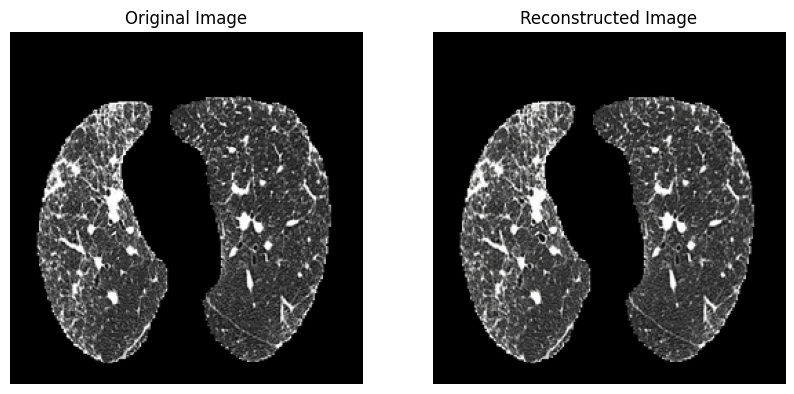

In [9]:
import matplotlib.pyplot as plt
import logging
logging.getLogger("PIL").setLevel(logging.WARNING)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))


axes[0].imshow(img_orig[0])
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(img_recon[0])
axes[1].set_title('Reconstructed Image')
axes[1].axis('off')